# Fleet-level time-explicit LCA of electric vehicles — explicit process/product

This notebook is a streamlined re-implementation of [the fleet EV example](./example_electric_vehicle_fleet.ipynb)
using the **explicit process/product paradigm** available in Brightway.

## What "explicit process/product" means

Brightway supports more than one inventory modelling style. See the Brightway docs on
[processes, products, and something in between](https://docs.brightway.dev/en/latest/content/overview/inventory.html#processes-products-and-something-in-between)
for the broader discussion. In the common chimaera style, one node acts as both **a process**
(the operation) and **its reference product** (the unit it outputs). This is compact and widely
used in existing LCI databases.

The explicit paradigm separates them:

- A **product node** (`type=bd.labels.product_node_default`) is a *thing* — a kg of methanol, a
  vehicle-lifetime, a kWh. It carries no exchanges and has no `reference product` field of its
  own; it just sits in the system as a row of the technosphere matrix that you can *demand*.
- A **process node** (`type=bd.labels.process_node_default`) is an *operation*. All its
  technosphere/biosphere/production edges live here. Its only "output" is one (or more)
  production edges pointing at product nodes.

With the two split, every product node has a clean **upstream side** (the process(es)
producing it) and **downstream side** (the consumers demanding it). That separation is useful
when temporal meaning belongs directly to the product output edge. It is a modelling choice,
not a universal requirement: the same broad LCA question can often be modelled with chimaera
nodes plus an intermediary foreground activity, or with explicit process/product nodes. This
notebook chooses the explicit option because production-year timing can then live directly on the
process→product production edge.

## Terminology used in this notebook

A **production-time group** is a group of vehicles produced in the same year. Fleet and stock
models often call this a **cohort**; for example, all vehicles produced in 2030 are the 2030
cohort. In this notebook, we use plain phrases such as production-year group in the text and
reserve `cohort` mostly for flodym variable names like `stock_by_cohort`.

A **process/product version date** is the production or purchase date that fixes a vehicle
property, such as kWh/km. Some literature calls this a **vintage**. For example, a vehicle
produced in 2020 keeps the efficiency associated with the 2020 process/product version. If that
property is production-year-locked, the vehicle keeps it while driving in later years.

## What this notebook does

1. We use [**flodym**](https://github.com/pik-piam/flodym) to run a stock-driven dynamic
   Material Flow Analysis (dMFA) of an EV fleet. flodym gives us, from an exogenous stock
   trajectory and a Weibull lifetime distribution, three things: the annual inflow (production),
   the `stock_by_cohort` matrix (which production-year groups are on the road in which year), and the age-resolved
   survival/retirement profiles. These become the relative `TemporalDistribution`s we feed to
   `bw_timex`.
2. We model the fleet with **a single foreground process + a single product**: no aggregator
   wrapper, no per-vehicle build/EOL sub-processes. The production-year timing rides on the *production*
   edge `ev_fleet_process → ev_fleet_product`; the age-relative TDs ride on the technosphere
   edges of `ev_fleet_process`. `temporal_evolution_factors` with `reference="consumer"` on the
   electricity edge then track **production-year-locked efficiencies**: a vehicle built in 2020 keeps
   its 2020 kWh/km even when it is still driving in 2030 alongside vehicles from more efficient production-year groups.

What this gives us: in any calendar year (e.g. 2030) `bw_timex` evaluates the fleet's
electricity demand by production-year group — older production-year groups consuming more, newer production-year groups consuming
less — at the same time as the background system itself decarbonises.

> **Note:** Fully reproducible — only requires `bw_timex`, `flodym`, `numpy`, `pandas`,
> `matplotlib`, `scipy`. We use tiny made-up background databases for 2020/2030/2040 instead
> of ecoinvent or premise.


## Project and background databases


In [1]:
import bw2data as bd

bd.projects.set_current("electric_vehicle_fleet_explicit")
for db in list(bd.databases):
    del bd.databases[db]


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.11/site-packages/bw2calc/__init__.py:54: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


We register a one-flow biosphere and three time-stamped background databases (2020, 2030, 2040).
Every background process emits CO2 only, and the per-unit emissions decrease over time, representing
a decarbonising background system.


In [2]:
biosphere = bd.Database("biosphere")
biosphere.register()
biosphere.write({("biosphere", "CO2"): {"type": "emission", "name": "carbon dioxide"}})

background_2020 = bd.Database("background_2020"); background_2020.register(); background_2020.write({})
background_2030 = bd.Database("background_2030"); background_2030.register(); background_2030.write({})
background_2040 = bd.Database("background_2040"); background_2040.register(); background_2040.write({})

background_databases = [background_2020, background_2030, background_2040]

process_co2_emissions = {
    "glider":         (10,   5,    2.5),    # kg CO2 / kg in 2020, 2030, 2040
    "powertrain":     (20,   10,   7.5),
    "battery":        (10,   5,    4),
    "electricity":    (0.5,  0.25, 0.075),  # kg CO2 / kWh
    "glider_eol":     (0.01, 0.0075, 0.005),
    "powertrain_eol": (0.01, 0.0075, 0.005),
    "battery_eol":    (1,    0.5,  0.25),
}

node_co2 = biosphere.get("CO2")
for component_name, gwis in process_co2_emissions.items():
    for database, gwi in zip(background_databases, gwis):
        database.new_node(component_name, name=component_name, location="somewhere").save()
        component = database.get(component_name)
        component["reference product"] = component_name
        component.save()
        production_amount = -1 if "eol" in component_name else 1
        component.new_edge(input=component, amount=production_amount, type="production").save()
        component.new_edge(input=node_co2, amount=gwi, type="biosphere").save()


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 7397.36it/s]

10:16:09+0200 [info     ] Vacuuming database            


## Per-vehicle assumptions

We keep the same simple bill-of-materials and use-phase parameters as in the standalone notebook.
These are applied *per vehicle*; the flodym stock model below scales them to the fleet.


In [3]:
ELECTRICITY_CONSUMPTION = 0.2      # kWh/km (2020 production-year baseline)
ANNUAL_MILEAGE          = 12_000   # km/year per vehicle in stock

MASS_GLIDER     = 840   # kg
MASS_POWERTRAIN = 80    # kg
MASS_BATTERY    = 280   # kg


## Dynamic stock model with flodym

We solve a stock-driven dMFA on an annual grid from 2015 to 2055:

- An exogenously prescribed S-curve stock trajectory.
- A Weibull lifetime (shape `k = 5`, scale `lambda = 14` years, mean ~13 years).

From this, flodym returns annual inflow, outflow and the `stock_by_cohort` matrix. In flodym's
terminology, a cohort is a production-year group, so this matrix says how many vehicles produced
in each year are still on the road in each later year.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

from flodym import (
    Dimension,
    DimensionSet,
    StockArray,
    StockDrivenDSM,
    WeibullLifetime,
)


In [5]:
YEAR_START = 2015
YEAR_END   = 2055
years = np.arange(YEAR_START, YEAR_END + 1)

time_dim = Dimension(name="Time", letter="t", items=years.tolist(), dtype=int)
dims = DimensionSet(dim_list=[time_dim])

STOCK_SATURATION = 2_000_000
STOCK_MIDPOINT   = 2030
STOCK_STEEPNESS  = 0.35
stock_values = STOCK_SATURATION / (1 + np.exp(-STOCK_STEEPNESS * (years - STOCK_MIDPOINT)))
stock = StockArray(dims=dims, name="ev_fleet", values=stock_values)

WEIBULL_SHAPE = 5.0
WEIBULL_SCALE = 14.0
lifetime_model = WeibullLifetime(dims=dims)
lifetime_model.set_prms(
    weibull_shape=np.full(dims.shape, WEIBULL_SHAPE),
    weibull_scale=np.full(dims.shape, WEIBULL_SCALE),
)

dsm = StockDrivenDSM(dims=dims, stock=stock, lifetime_model=lifetime_model)
dsm.compute()

inflow_values  = dsm.inflow.values
outflow_values = dsm.outflow.values
stock_by_cohort = dsm.get_stock_by_cohort()  # shape (year, cohort), strictly upper triangular


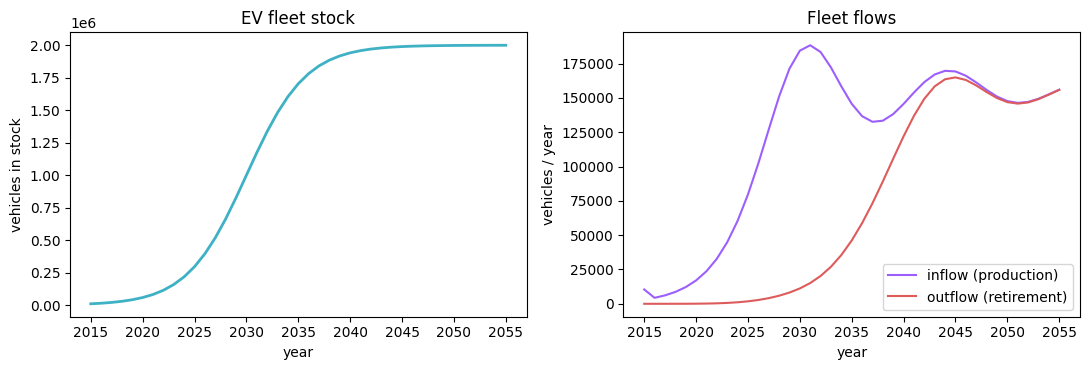

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(years, dsm.stock.values, color="#3fb1c5", lw=2)
axes[0].set(xlabel="year", ylabel="vehicles in stock", title="EV fleet stock")
axes[1].plot(years, inflow_values,  label="inflow (production)",  color="#9c5ffd")
axes[1].plot(years, outflow_values, label="outflow (retirement)", color="#dd5b5b")
axes[1].set(xlabel="year", ylabel="vehicles / year", title="Fleet flows")
axes[1].legend()
fig.tight_layout()


### Stock by production-year group: who is on the road in 2030?

The `stock_by_cohort` matrix is the key object motivating this notebook. Here, flodym uses cohort to mean all vehicles produced in the same year. Picking a single calendar
year (e.g. 2030) and stacking the column tells us how the fleet on the road that year decomposes
into vehicles produced in earlier production years. That decomposition is what `bw_timex` will replicate
from our two TDs (production-year × age) — and what makes production-year-specific `temporal_evolution_factors`
meaningful.


In 2030: 1,000,000 vehicles in service, oldest production-year group still on the road: 2015.


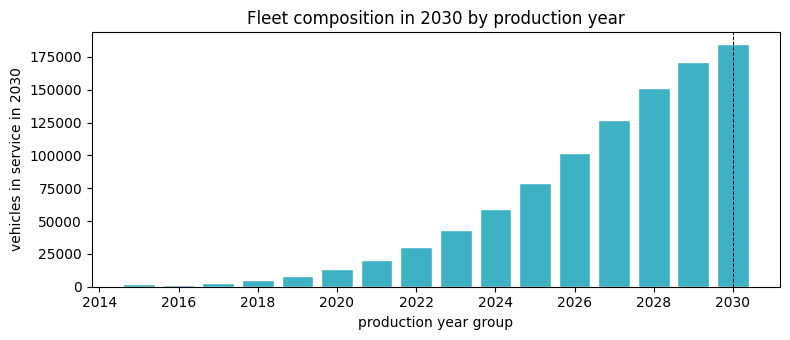

In [7]:
TARGET_YEAR = 2030
yr_idx = int(np.where(years == TARGET_YEAR)[0][0])
stock_in_target_year = stock_by_cohort[yr_idx, : yr_idx + 1]
production_years_in_target = years[: yr_idx + 1]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(production_years_in_target, stock_in_target_year, color="#3fb1c5", edgecolor="white")
ax.set(xlabel="production year group",
       ylabel=f"vehicles in service in {TARGET_YEAR}",
       title=f"Fleet composition in {TARGET_YEAR} by production year")
ax.axvline(TARGET_YEAR, color="k", ls="--", lw=0.7)
fig.tight_layout()

print(f"In {TARGET_YEAR}: {stock_in_target_year.sum():,.0f} vehicles in service, "
      f"oldest production-year group still on the road: {production_years_in_target[stock_in_target_year > 1][0]}.")


### Restrict the production-year window

We scope the LCA to vehicles whose production year falls in `[ANALYSIS_START, ANALYSIS_END]`. This
keeps the build phase entirely within the horizon of our background databases. The use phase and
end-of-life of these production-year groups may extend past `ANALYSIS_END`, which is exactly what `bw_timex` is
designed to handle.


In [8]:
ANALYSIS_START = 2020
ANALYSIS_END   = 2050
FU_YEAR        = 2035   # anchoring year for the TimexLCA timeline

mask = (years >= ANALYSIS_START) & (years <= ANALYSIS_END)
years_window  = years[mask]
inflow_window = inflow_values[mask]
n_total_inflow = float(inflow_window.sum())

print(f"Production-year window: {ANALYSIS_START}-{ANALYSIS_END}")
print(f"Total vehicles produced in window: {n_total_inflow:>12,.0f}")


Production-year window: 2020-2050
Total vehicles produced in window:    4,132,670


## From flodym to `TemporalDistribution`s

Three flodym outputs become three relative TDs that we hang on the foreground edges:

```{mermaid}
flowchart LR
    stock[stock trajectory<br/>S-curve]:::in --> dsm
    lt[Weibull lifetime<br/>shape k, scale &lambda;]:::in --> dsm
    dsm{{flodym StockDrivenDSM}}:::dsm
    dsm --> inflow[annual inflow<br/>vehicles / year]:::out
    dsm --> sf[survival function<br/>P&#40;age&#41;]:::out
    dsm --> pdf[retirement PDF<br/>p&#40;age&#41;]:::out
    inflow -->|normalise| td_prod([td_production_inflow<br/>calendar-year axis]):::td
    sf     -->|normalise| td_use([td_use_age<br/>age axis]):::td
    pdf    -->|normalise| td_eol([td_eol_age<br/>age axis]):::td
    td_prod -.attached to.-> e1[production edge<br/>process &rarr; product]:::edge
    td_use    -.attached to.-> e2[electricity edge]:::edge
    td_eol    -.attached to.-> e3[EOL edges &times;3]:::edge

    classDef in   color:#222832, fill:#e8e8e8, stroke:none;
    classDef dsm  color:#ffffff, fill:#222832, stroke:none;
    classDef out  color:#222832, fill:#cfe9f0, stroke:none;
    classDef td   color:#222832, fill:#9c5ffd, stroke:none;
    classDef edge color:#222832, fill:#3fb1c5, stroke:none;
```

1. The **production-year TD** (`td_production_inflow`) lives on the *production edge* from
   `ev_fleet_process` to `ev_fleet_product`. It is in **calendar-year offsets** (relative to
   `FU_YEAR`) and its weights are the per-year inflow shares from flodym. Putting it here means:
   when something demands the product, the producing process runs *once per production year*. Each of
   those production-year instances inherits a distinct `date_consumer` (= the production year) on every
   exchange below.
2. The **age-relative TDs** (`td_use_age`, `td_eol_age`) live on the technosphere edges of
   `ev_fleet_process`:
   - on the electricity edge: the Weibull *survival function* over vehicle ages — each production-year group
     uses electricity for as long as its vehicles are still on the road;
   - on the EOL edges: the Weibull *retirement PDF* over vehicle ages — each production-year group eventually
     retires.

These two layers **convolve** inside `bw_timex`. For a production-year group produced in year `c`, an age TD
with weight `w` at age `a` contributes to the calendar year `c + a`. Sum over all production-year groups and
all ages, and you recover the same calendar-year x production-year grid that flodym's `stock_by_cohort`
matrix describes — but expressed compactly as two normalised TDs instead of a `len(years) ×
len(ages)` matrix of bespoke timestamps.

**Convention.** `TD.amount × edge.amount` gives the absolute per-time quantity. We always
normalise the TD weights to sum to 1 and put the absolute per-vehicle scaling on the edge
amount.


In [9]:
from bw_temporalis import TemporalDistribution

# 1) Production-year TD on the production edge (calendar years relative to FU_YEAR)
production_offsets = (years_window - FU_YEAR).astype("int64").astype("timedelta64[Y]")
production_shares  = inflow_window / inflow_window.sum()
td_production_inflow = TemporalDistribution(date=production_offsets, amount=production_shares)

# 2) Age-relative TDs (vehicle-age axis, relative to each production year)
ages = np.arange(0, 40)
weibull_sf  = weibull_min.sf(ages,  c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)
weibull_pdf = weibull_min.pdf(ages, c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)

mean_lifetime_years = float(weibull_sf.sum())  # discrete mean lifetime ~= sum of survival probs

sf_mask = weibull_sf > 0
td_use_age = TemporalDistribution(
    date=ages[sf_mask].astype("timedelta64[Y]"),
    amount=weibull_sf[sf_mask] / mean_lifetime_years,  # weights sum to 1
)

pdf_mask = weibull_pdf > 0
td_eol_age = TemporalDistribution(
    date=ages[pdf_mask].astype("timedelta64[Y]"),
    amount=weibull_pdf[pdf_mask] / weibull_pdf[pdf_mask].sum(),
)


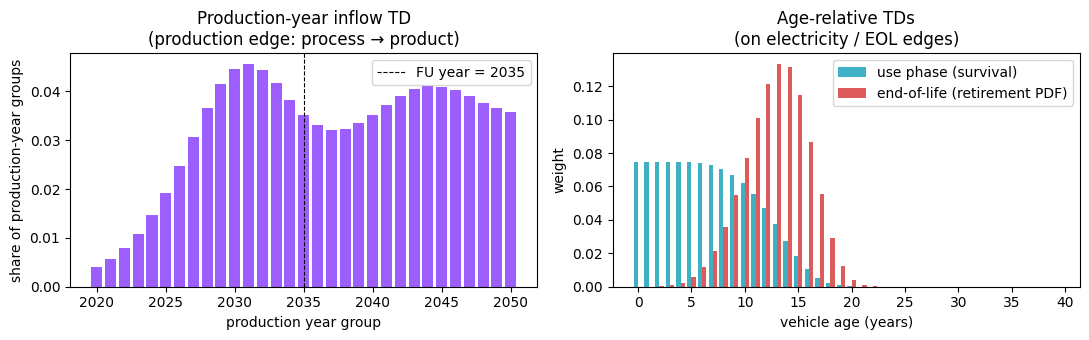

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(years_window, td_production_inflow.amount, color="#9c5ffd")
axes[0].axvline(FU_YEAR, color="k", ls="--", lw=0.8, label=f"FU year = {FU_YEAR}")
axes[0].set(xlabel="production year group", ylabel="share of production-year groups",
            title="Production-year inflow TD\n(production edge: process \u2192 product)")
axes[0].legend()

use_age_int = td_use_age.date.astype("timedelta64[Y]").astype(int)
eol_age_int = td_eol_age.date.astype("timedelta64[Y]").astype(int)
axes[1].bar(use_age_int - 0.2, td_use_age.amount, width=0.4, color="#3fb1c5",
            label="use phase (survival)")
axes[1].bar(eol_age_int + 0.2, td_eol_age.amount, width=0.4, color="#dd5b5b",
            label="end-of-life (retirement PDF)")
axes[1].set(xlabel="vehicle age (years)", ylabel="weight",
            title="Age-relative TDs\n(on electricity / EOL edges)")
axes[1].legend()
fig.tight_layout()


## Production-year efficiency factors

We assume EVs get more efficient at the time of purchase: a vehicle built in 2020 uses
`ELECTRICITY_CONSUMPTION` kWh/km, but later production-year groups use less. Numbers below are made up
(~0.7%/year improvement) — swap in whatever your scenario calls for.

**Why the explicit product node helps here.** You can model fleet production-year groups with either chimaera
nodes plus an intermediary foreground activity, or with separate process and product nodes. The
explicit product node makes the timing easier to read: production-year timing sits directly on the
production edge, and use-phase timing sits on the electricity input edge. The result is two
timestamps that ride together through the graph:

- `date_consumer` = the production/purchase year of the consuming foreground process instance;
- `date_producer` = the calendar date of the actual input/output event, e.g. electricity use in a later year.

`temporal_evolution_factors` must be evaluated against one of those dates. The reference choice is a modelling statement:

### `temporal_evolution_reference="consumer"`

Use this when the exchange amount is a **property of the vehicle production/purchase year**. The factor is evaluated at `date_consumer`, the production year. A 2020 vehicle keeps its 2020 kWh/km even when it drives in 2040; a 2035 vehicle keeps its 2035 kWh/km during later use. This is production-year locking.

This notebook uses `"consumer"`, because electricity efficiency is assumed to be fixed by the vehicle design at purchase.

### `temporal_evolution_reference="producer"`

Use this when the exchange amount is a **property of the calendar year when the event happens**. The factor is evaluated at `date_producer`. In the EV case, that would mean all vehicles driving in 2040 use the 2040 factor, regardless of whether they were produced in 2020, 2030, or 2035. This would represent a system-wide retrofit, operational learning, or a foreground use-phase technology that updates for all active production years.

Rule of thumb:

```text
Is the change a property of the foreground process/product production year?
-> use consumer

Is the change a property of the calendar year when the exchange happens?
-> use producer
```

In this fleet model, `consumer` gives us production-year-specific vehicle efficiencies while `bw_timex` still uses `date_producer` to relink electricity generation to the correct time-stamped background database.


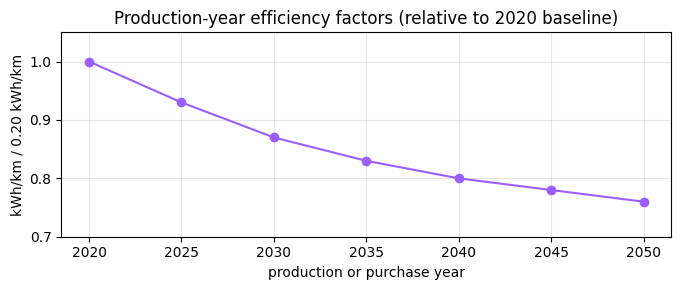

In [11]:
from datetime import datetime

production_year_efficiency_factors = {
    datetime(2020, 1, 1): 1.00,
    datetime(2025, 1, 1): 0.93,
    datetime(2030, 1, 1): 0.87,
    datetime(2035, 1, 1): 0.83,
    datetime(2040, 1, 1): 0.80,
    datetime(2045, 1, 1): 0.78,
    datetime(2050, 1, 1): 0.76,
}

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot([d.year for d in production_year_efficiency_factors],
        list(production_year_efficiency_factors.values()),
        marker="o", color="#9c5ffd")
ax.set(xlabel="production or purchase year",
       ylabel=f"kWh/km / {ELECTRICITY_CONSUMPTION:.2f} kWh/km",
       title="Production-year efficiency factors (relative to 2020 baseline)",
       ylim=(0.7, 1.05))
ax.grid(alpha=0.3)
fig.tight_layout()


## Foreground system — explicit process and product

The whole foreground is **one product** (`ev_fleet_product`) and **one process**
(`ev_fleet_process`). Compare to the original example with four foreground nodes
(`fleet_service`, `fleet_driving`, `ev_production`, `used_ev`) — the explicit paradigm collapses
all of that into the dual structure below.

```{mermaid}
flowchart LR
    glider(glider production):::ei-->ev_fleet_process
    powertrain(powertrain production):::ei-->ev_fleet_process
    battery(battery production):::ei-->ev_fleet_process
    electricity(electricity generation):::ei-->|age survival TD<br/>+ production-year factors|ev_fleet_process
    ev_fleet_process(EV fleet process):::fg-->|production-year inflow TD<br/>production edge|ev_fleet_product([EV fleet product]):::fg
    ev_fleet_process-->|age retirement TD|glider_eol(glider eol):::ei
    ev_fleet_process-->|age retirement TD|powertrain_eol(powertrain eol):::ei
    ev_fleet_process-->|age retirement TD|battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

### What each node is, and why

**`ev_fleet_product`** is a *thing*: the abstract "vehicle-lifetime" unit of fleet service. It is
deliberately bare — `name`, `unit`, `type=bd.labels.product_node_default`, no exchanges, no
`reference product`. Its only job is to be the **demand handle**: the FU is
`{ev_fleet_product: n_total_inflow}`. Because it sits as its own technosphere row, we can attach
TDs to *its incoming and outgoing edges* without those TDs ever being conflated with the
process operation that produced it.

**`ev_fleet_process`** is the *operation*: the per-production-year-vehicle life-cycle. All technosphere
and biosphere edges live here:

- *Build* edges (glider, powertrain, battery): per-vehicle masses, no TD — the build is treated
  as a point event at the production year (age 0).
- *Use* edge (electricity): lifetime kWh per vehicle, with the **age survival TD** spreading
  consumption across the vehicle's lifetime, and `temporal_evolution_factors` (consumer-ref)
  scaling each production-year group by its production-year efficiency.
- *EOL* edges (glider/powertrain/battery EOL): per-vehicle masses with the **age retirement
  PDF** TD — each production-year group retires at a Weibull-distributed age.

Note what `ev_fleet_process` does *not* have: a `reference product` field, a self-production
edge, or any embedded product knowledge. The product is a separate node, reached only via the
production edge with the production-year TD on it.

### TDs on both "sides" of the product

This is the core of the modelling pattern. The product node has two sides:

- **Upstream (production) side** — the edge `ev_fleet_process → ev_fleet_product`. Its TD says
  *when production happens* relative to the demand. Here this is the **production-year TD**: a calendar-year
  distribution that places one production event per production year, weighted by inflow share.
- **Downstream (consumption) side** — edges from any consumer of the product, including the
  functional unit itself. Their TDs say *when the product is being consumed*. In this notebook
  the only consumer is the FU, which is anchored at `FU_YEAR` with no TD (a point mass at
  `FU_YEAR`). In a richer model — e.g. a downstream taxi service consuming `ev_fleet_product`
  with its own demand profile — that consumer's TD would also live on this side.

When `bw_timex` evaluates the system, it **convolves these two sides at the product node**.
The consumer TD shifts the demand profile through time; the production TD then says *for each
demand instant* when the producing process actually ran. The composite result is propagated
downward into every exchange of `ev_fleet_process` as a `(date_consumer, date_producer)` pair.
Concretely:

- `date_consumer` = production year (the moment the product instance was "made")
- `date_producer` = calendar year of the actual technosphere/biosphere event (production year +
  age, for use/EOL edges)

That double-indexing is what makes the rest of the model expressive. `bw_timex` automatically
relinks each exchange to the right time-stamped background database based on `date_producer`,
so vehicles built in 2025 source materials and electricity at dates derived from the 2025 production year and electricity. And
`temporal_evolution_factors` with `reference="consumer"` evaluates the foreground efficiency
factor at the *production year* (`date_consumer`) — not the electricity-use year (`date_producer`) —
so production-year locking falls out for free.

All amounts on the process edges are *per production-year vehicle*. The total fleet scaling enters via
the FU demand: `{ev_fleet_product: n_total_inflow}`.


### Step 1 — define the two foreground nodes

The product is bare metadata: just `name`, `unit`, and `type=bd.labels.product_node_default`.
We deliberately do *not* set a `reference product` field on it (it *is* the reference
product). The process gets `name`, `location`, and `type=bd.labels.process_node_default` — also
no `reference product`, since the production edge below points explicitly at the product.


In [12]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]
foreground = bd.Database("foreground")
foreground.register()

ev_fleet_product = foreground.new_node(
    code="ev_fleet_product",
    name="EV fleet vehicle-lifetime",
    unit="vehicle-lifetime",
    type=bd.labels.product_node_default,
)
ev_fleet_product.save()

ev_fleet_process = foreground.new_node(
    code="ev_fleet_process",
    name="EV fleet operation (per production-year vehicle, life-cycle)",
    location="GLO",
    type=bd.labels.process_node_default,
)
ev_fleet_process.save()


### Step 2 — wire up the edges (all on the process)

All edges live on `ev_fleet_process`. The product never carries an exchange. We start with the
**production edge** that connects the two — this is where the production-year TD goes — and then add the
build / use / EOL technosphere edges, with their respective age-relative TDs.


In [13]:
# Pull background activities (we use the 2020 names; bw_timex relinks them across DBs at runtime).
glider_node      = background_2020.get(code="glider")
powertrain_node  = background_2020.get(code="powertrain")
battery_node     = background_2020.get(code="battery")
electricity_node = background_2020.get(code="electricity")
glider_eol       = background_2020.get(code="glider_eol")
powertrain_eol   = background_2020.get(code="powertrain_eol")
battery_eol      = background_2020.get(code="battery_eol")

# --- Upstream side of the product: production edge (process -> product). ---
# Amount = 1 vehicle-lifetime per production-year vehicle. The production-year TD splits this into one
# production event per production year, weighted by inflow share.
ev_fleet_process.new_edge(
    input=ev_fleet_product,
    amount=1,
    type=bd.labels.production_edge_default,
    temporal_distribution=td_production_inflow,
).save()

# --- Build phase: per-vehicle masses, point mass at age 0 (no TD = at the production year). ---
ev_fleet_process.new_edge(
    input=glider_node, amount=MASS_GLIDER, type=bd.labels.consumption_edge_default,
).save()
ev_fleet_process.new_edge(
    input=powertrain_node, amount=MASS_POWERTRAIN, type=bd.labels.consumption_edge_default,
).save()
ev_fleet_process.new_edge(
    input=battery_node, amount=MASS_BATTERY, type=bd.labels.consumption_edge_default,
).save()

# --- Use phase: lifetime kWh per vehicle, spread over ages by the survival TD. ---
# `temporal_evolution_reference="consumer"` makes the production-year factor evaluate at the
# production/version date (`date_consumer`), not the electricity-use date (`date_producer`).
# Use "producer" instead only if the foreground efficiency should follow the calendar
# year of the use event for all active production years.
electricity_edge = ev_fleet_process.new_edge(
    input=electricity_node,
    amount=ANNUAL_MILEAGE * ELECTRICITY_CONSUMPTION * mean_lifetime_years,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=td_use_age,
)
electricity_edge["temporal_evolution_factors"]   = production_year_efficiency_factors
electricity_edge["temporal_evolution_reference"] = "consumer"
electricity_edge.save()

# --- End-of-life: one retirement event per vehicle, distributed over ages by the PDF TD. ---
ev_fleet_process.new_edge(
    input=glider_eol, amount=-MASS_GLIDER,
    type=bd.labels.consumption_edge_default, temporal_distribution=td_eol_age,
).save()
ev_fleet_process.new_edge(
    input=powertrain_eol, amount=-MASS_POWERTRAIN,
    type=bd.labels.consumption_edge_default, temporal_distribution=td_eol_age,
).save()
ev_fleet_process.new_edge(
    input=battery_eol, amount=-MASS_BATTERY,
    type=bd.labels.consumption_edge_default, temporal_distribution=td_eol_age,
).save()

for db in bd.databases:
    bd.Database(db).process()


## Characterization method


In [14]:
bd.Method(("GWP", "example")).write([(("biosphere", "CO2"), 1)])
method = ("GWP", "example")


## Time-explicit fleet LCA

We anchor the timeline at `FU_YEAR` (2035) by passing it as `starting_datetime` to
`build_timeline`. All offsets in our TDs are interpreted relative to that anchor. The functional
unit is `n_total_inflow` units of `ev_fleet_product` — i.e. the entire fleet over the analysis
horizon.


In [15]:
from bw_timex import TimexLCA

database_dates = {
    "background_2020": datetime.strptime("2020", "%Y"),
    "background_2030": datetime.strptime("2030", "%Y"),
    "background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",
}

tlca = TimexLCA(
    demand={ev_fleet_product: n_total_inflow},
    method=method,
    database_dates=database_dates,
)
tlca.build_timeline(
    starting_datetime=datetime(FU_YEAR, 1, 1),
    temporal_grouping="year",
)


2026-05-04 10:16:10.454 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-04 10:16:10.454 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-04 10:16:10.463 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-04 10:16:10.465 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-04 10:16:10.466 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-04 10:16:11.843 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-04 10:16:11.843 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-04 10:16:11.843 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-04 10:16:11.843 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2020-01-01,glider,2020-01-01,EV fleet operation (per production-year vehicl...,840.0,{'background_2020': 1}
1,2020-01-01,powertrain,2020-01-01,EV fleet operation (per production-year vehicl...,80.0,{'background_2020': 1}
2,2020-01-01,battery,2020-01-01,EV fleet operation (per production-year vehicl...,280.0,{'background_2020': 1}
3,2020-01-01,electricity,2020-01-01,EV fleet operation (per production-year vehicl...,2400.00007,{'background_2020': 1}
4,2020-01-01,EV fleet operation (per production-year vehicl...,2020-01-01,-1,17030.382713,None
...,...,...,...,...,...,...
4986,2088-01-01,battery_eol,2050-01-01,EV fleet operation (per production-year vehicl...,-0.0,{'background_2040': 1}
4987,2089-01-01,electricity,2050-01-01,EV fleet operation (per production-year vehicl...,0.0,{'background_2040': 1}
4988,2089-01-01,glider_eol,2050-01-01,EV fleet operation (per production-year vehicl...,-0.0,{'background_2040': 1}
4989,2089-01-01,powertrain_eol,2050-01-01,EV fleet operation (per production-year vehicl...,-0.0,{'background_2040': 1}


In [16]:
tlca.lci()
tlca.static_lcia()
print(f"Time-explicit fleet GWP: {tlca.static_score:>14,.0f} kg CO2-eq")
print(f"Static (2020 background) fleet GWP: {tlca.base_lca.score:>14,.0f} kg CO2-eq")
print(f"\nPer-vehicle GWP, time-explicit: {tlca.static_score / n_total_inflow:>10,.0f} kg CO2-eq / vehicle")
print(f"Per-vehicle GWP, static (2020): {tlca.base_lca.score / n_total_inflow:>10,.0f} kg CO2-eq / vehicle")


2026-05-04 10:16:11.887 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-04 10:16:31.408 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


Time-explicit fleet GWP: 23,644,975,605 kg CO2-eq
Static (2020 background) fleet GWP: 120,320,351,786 kg CO2-eq

Per-vehicle GWP, time-explicit:      5,721 kg CO2-eq / vehicle
Per-vehicle GWP, static (2020):     29,114 kg CO2-eq / vehicle


### Dynamic characterization


Cumulative fleet radiative forcing: 1.802e-03 W/m²


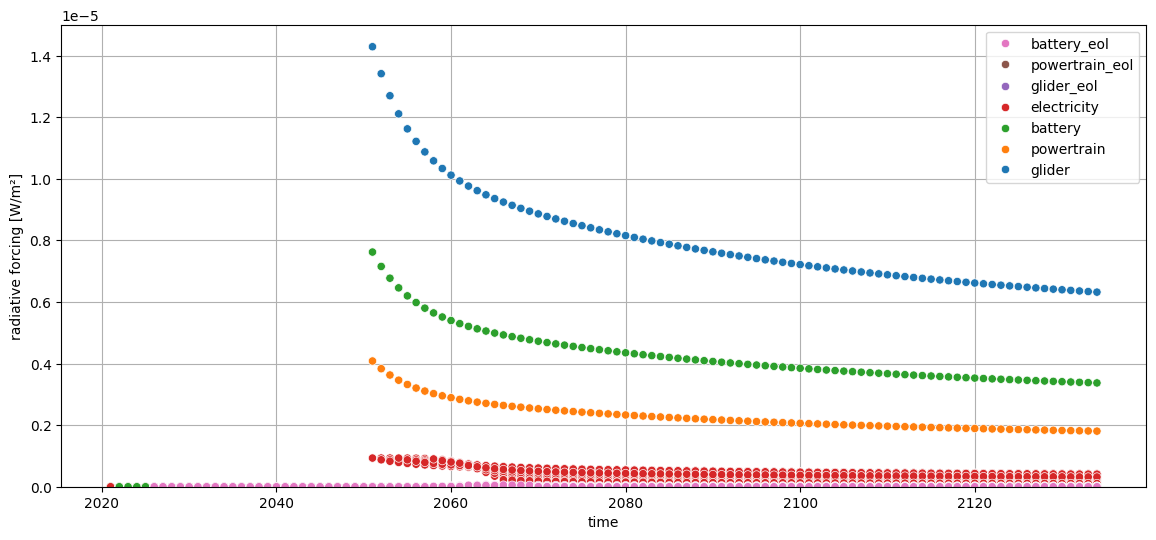

In [17]:
from dynamic_characterization.ipcc_ar6.radiative_forcing import characterize_co2

characterization_functions = {bd.get_node(code="CO2").id: characterize_co2}

tlca.dynamic_lcia(
    metric="radiative_forcing",
    fixed_time_horizon=True,
    characterization_functions=characterization_functions,
)
print(f"Cumulative fleet radiative forcing: {tlca.dynamic_score:.3e} W/m\u00b2")
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)


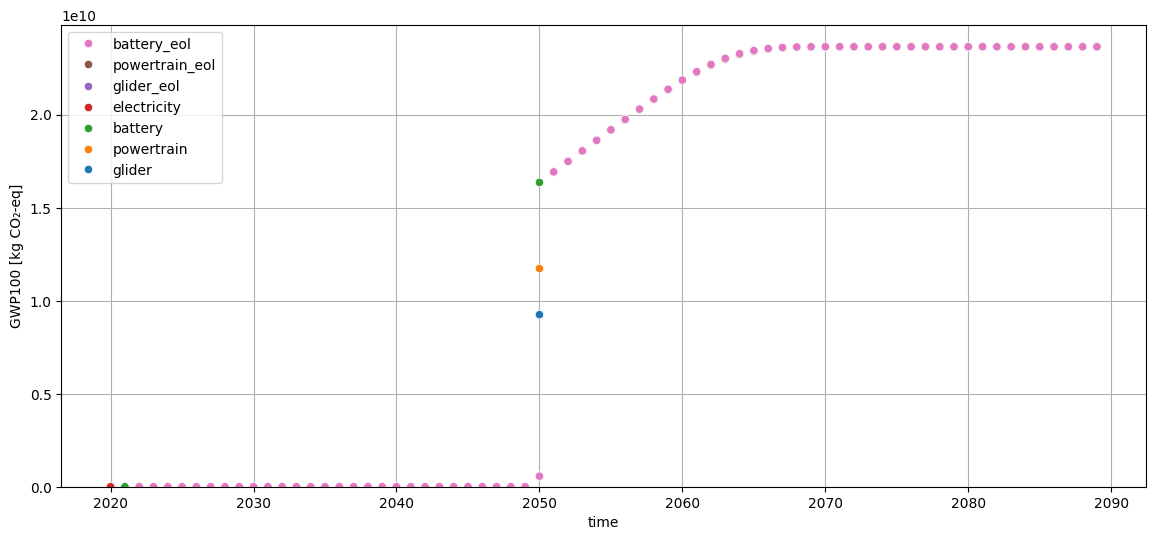

In [18]:
tlca.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)


## Validating production-year tracking

We can check that `bw_timex` is doing what we expect by comparing its prediction to a hand-rolled
calculation that uses *only* flodym outputs and the production-year factors. For a fixed calendar year
`y`, the electricity consumption attributable to the vehicle group produced in year `c` is

$$E_{c,y} \;=\; \text{stock\_by\_cohort}[y, c] \;\times\; \text{ANNUAL\_MILEAGE} \;\times\;
\text{ELECTRICITY\_CONSUMPTION} \;\times\; f_{\text{production-year}}(c).$$

Summed over `c`, this gives the year-`y` fleet electricity demand. The plot below shows that
decomposition for `TARGET_YEAR = 2030`: the bars are the per-production-year kWh, and their colour encodes
the production-year efficiency factor. Older production-year groups contribute disproportionally more electricity (and
emissions) per vehicle — exactly the production-year locking behaviour `temporal_evolution_factors` with
`reference="consumer"` encodes inside `bw_timex`.


Total fleet electricity in 2030: 2,178.6 GWh
  of which from production-year groups <= 2025: 606.4 GWh
  of which from production-year groups >  2025: 1,572.2 GWh


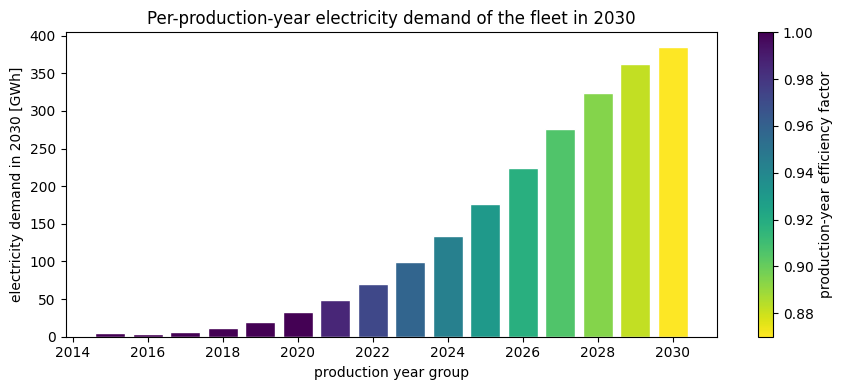

In [19]:
import matplotlib as mpl
from matplotlib.colors import Normalize

def production_year_factor_lookup(production_year: int) -> float:
    keys = sorted(production_year_efficiency_factors)
    yrs  = np.array([k.year for k in keys])
    vals = np.array([production_year_efficiency_factors[k] for k in keys])
    return float(np.interp(production_year, yrs, vals, left=vals[0], right=vals[-1]))

production_years_active = years[: yr_idx + 1]
vehicles_per_production_year = stock_by_cohort[yr_idx, : yr_idx + 1]
production_year_factors_active = np.array([production_year_factor_lookup(year) for year in production_years_active])

kwh_per_production_year = (
    vehicles_per_production_year
    * ANNUAL_MILEAGE
    * ELECTRICITY_CONSUMPTION
    * production_year_factors_active
)

norm = Normalize(vmin=production_year_factors_active.min(), vmax=production_year_factors_active.max())
cmap = mpl.cm.viridis_r
colors = cmap(norm(production_year_factors_active))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(production_years_active, kwh_per_production_year / 1e6, color=colors, edgecolor="white")
ax.set(xlabel="production year group",
       ylabel=f"electricity demand in {TARGET_YEAR} [GWh]",
       title=f"Per-production-year electricity demand of the fleet in {TARGET_YEAR}")
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax, label="production-year efficiency factor")
fig.tight_layout()

print(f"Total fleet electricity in {TARGET_YEAR}: {kwh_per_production_year.sum()/1e6:,.1f} GWh")
print(f"  of which from production-year groups <= 2025: {kwh_per_production_year[production_years_active <= 2025].sum()/1e6:,.1f} GWh")
print(f"  of which from production-year groups >  2025: {kwh_per_production_year[production_years_active >  2025].sum()/1e6:,.1f} GWh")


### Isolating the production-year locking effect

To make the contribution of production-year locking visible, we rerun the same model with the
`temporal_evolution_factors` removed from the electricity edge and compare the dynamic GWP100
score to the run that included them. Everything else (production-year distribution, age-relative TDs,
background interpolation) is identical, so the difference is attributable purely to the foreground
production-year modifier.


In [20]:
saved_factors   = electricity_edge["temporal_evolution_factors"]
saved_reference = electricity_edge["temporal_evolution_reference"]
del electricity_edge["temporal_evolution_factors"]
del electricity_edge["temporal_evolution_reference"]
electricity_edge.save()
bd.Database("foreground").process()

tlca_no_evo = TimexLCA(
    demand={ev_fleet_product: n_total_inflow},
    method=method,
    database_dates=database_dates,
)
tlca_no_evo.build_timeline(
    starting_datetime=datetime(FU_YEAR, 1, 1),
    temporal_grouping="year",
)
tlca_no_evo.lci()
tlca_no_evo.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)

# Restore so any downstream rerun stays consistent.
electricity_edge["temporal_evolution_factors"]   = saved_factors
electricity_edge["temporal_evolution_reference"] = saved_reference
electricity_edge.save()
bd.Database("foreground").process()

score_no_evo   = tlca_no_evo.dynamic_score
score_with_evo = tlca.dynamic_score
delta = score_no_evo - score_with_evo
print(f"Time-explicit, NO foreground evo   : {score_no_evo:>16,.0f} kg CO2-eq")
print(f"Time-explicit, WITH production-year factors: {score_with_evo:>16,.0f} kg CO2-eq")
print(f"Production-year efficiency savings           : {delta:>+16,.0f} kg CO2-eq "
      f"({delta / score_no_evo * 100:+.1f}%)")


2026-05-04 10:17:24.123 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-04 10:17:24.123 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-04 10:17:24.130 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-04 10:17:24.132 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-04 10:17:24.133 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-04 10:17:25.619 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2089-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-04 10:17:25.650 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-04 10:17:46.332 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.11/site-packages/scipy/sparse/_data.py:57: RuntimeWarning: overflow encountered in multiply
  self.data *= other


Time-explicit, NO foreground evo   :   26,029,148,003 kg CO2-eq
Time-explicit, WITH production-year factors:   23,644,975,605 kg CO2-eq
Production-year efficiency savings           :   +2,384,172,398 kg CO2-eq (+9.2%)


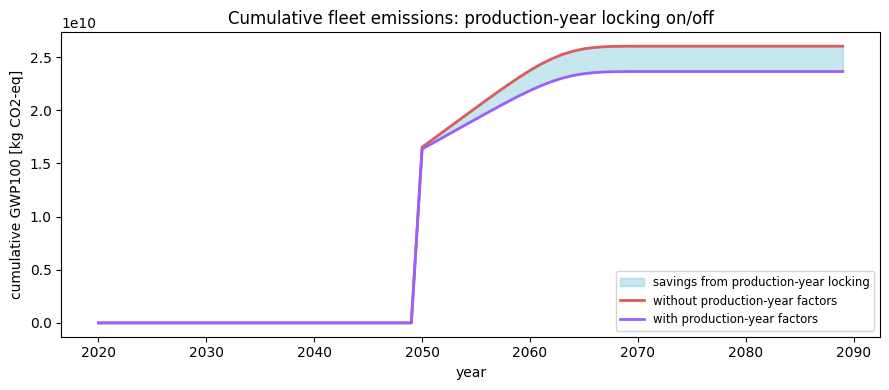

In [21]:
def yearly_total(tl):
    df = tl.characterized_inventory.copy()
    df["year"] = df["date"].dt.year
    return df.groupby("year")["amount"].sum()

yr_with    = yearly_total(tlca)
yr_without = yearly_total(tlca_no_evo)
years_idx  = sorted(set(yr_with.index) | set(yr_without.index))
yr_with    = yr_with.reindex(years_idx, fill_value=0)
yr_without = yr_without.reindex(years_idx, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(years_idx, yr_without.cumsum(), yr_with.cumsum(),
                color="#3fb1c5", alpha=0.3, label="savings from production-year locking")
ax.plot(years_idx, yr_without.cumsum(), color="#dd5b5b", lw=2, label="without production-year factors")
ax.plot(years_idx, yr_with.cumsum(),    color="#9c5ffd", lw=2, label="with production-year factors")
ax.set(xlabel="year", ylabel="cumulative GWP100 [kg CO2-eq]",
       title="Cumulative fleet emissions: production-year locking on/off")
ax.legend(loc="lower right", fontsize="small")
fig.tight_layout()


## Wrap-up

By moving to the explicit process/product paradigm, the fleet model collapses from four foreground
nodes (`fleet_service`, `fleet_driving`, `ev_production`, `used_ev`) to two: a single process and a
single product. The production-year timing rides on the production edge between them, and `bw_timex` does
the rest:

- automatic relinking of background inputs to the time-stamped databases (`background_2020/30/40`)
  at every production-year × age coordinate;
- temporal explosion via convolution of the production-year TD with the age TDs, so a single edge specification
  spawns the full production-year × calendar-year × age grid behind the scenes;
- per-production-year `temporal_evolution_factors` with `reference="consumer"`, which give us
  production-year-locked efficiencies — vehicles produced in 2020 keep their 2020 kWh/km even when they are
  still driving in 2030 alongside more efficient 2025 production-year groups.

The flodym layer is doing the dMFA bookkeeping (stock-driven inflow, `stock_by_cohort`, age survival
and retirement profiles) and feeds the resulting time series into `bw_timex` as relative
TDs. From here, you can plug in any other lifetime distribution (`NormalLifetime`,
`LogNormalLifetime`, …), any other stock trajectory, or richer production-year effects (e.g. production-year-specific
battery chemistry by adding additional production-year factors on dedicated edges).
